On 2D, the code proposed on the paper is not stable. I figured that maybe the solution to the stream function should be the 2D one so that it becomes stable and that is true.

- In 2D the only the only term in the derivative is the diffusion term, so would be interesting to analyze the differences between inviscid and viscid and how the viscosity changes the behaviour of the fluid considering vortices (maybe fake_tg scene) (viscanalysis2Dscene)
- There is actually moments where the energy is higher or lower. What is the cause the makes it shift?
- Kelvin–Helmholtz Instability
- taylor green periodic boundary?

In [2]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt


In [3]:
splishsplash_path = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/'
scenes_path = splishsplash_path + 'data/Scenes/'
output_path = splishsplash_path + 'output'
scene = 'DamBreakModel_2D'

In [4]:
folders = os.listdir(output_path + '/' + scene)
folders.remove('log')
print(folders)

['visc001']


## Base Dam Break example

In [5]:
folder_path = output_path + '/' + scene + '/' + 'visc001'
print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('log')

print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel_2D/visc001
['baseiine', 'vr10', 'vr10_deltaneg']


####  Energy

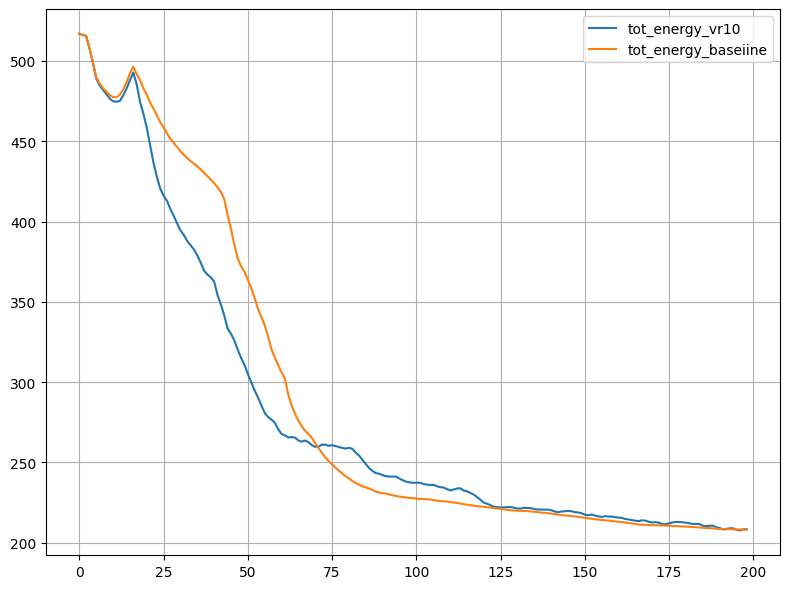

In [8]:
plt.figure(figsize=(8, 6))

# for folder in folders:
for folder in ['vr10','baseiine']:
    full_path = folder_path + '/' + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,200):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

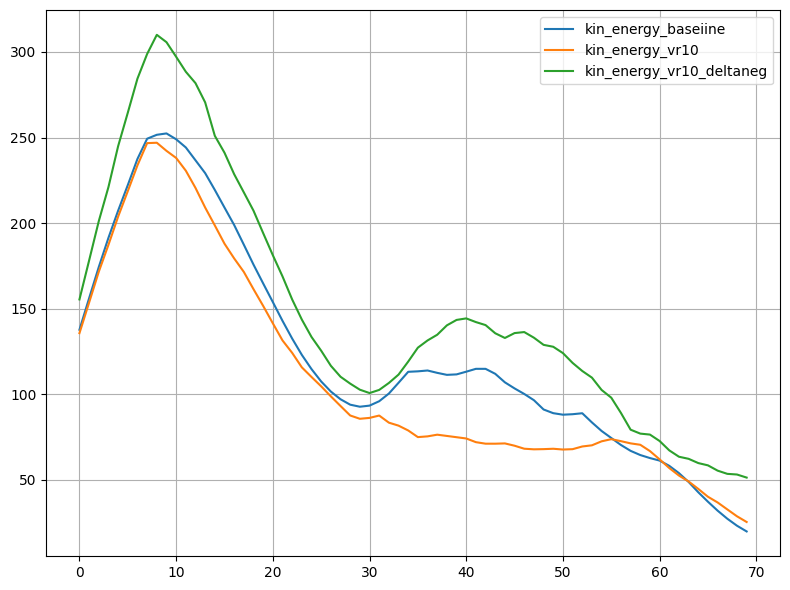

In [27]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path  + '/' + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

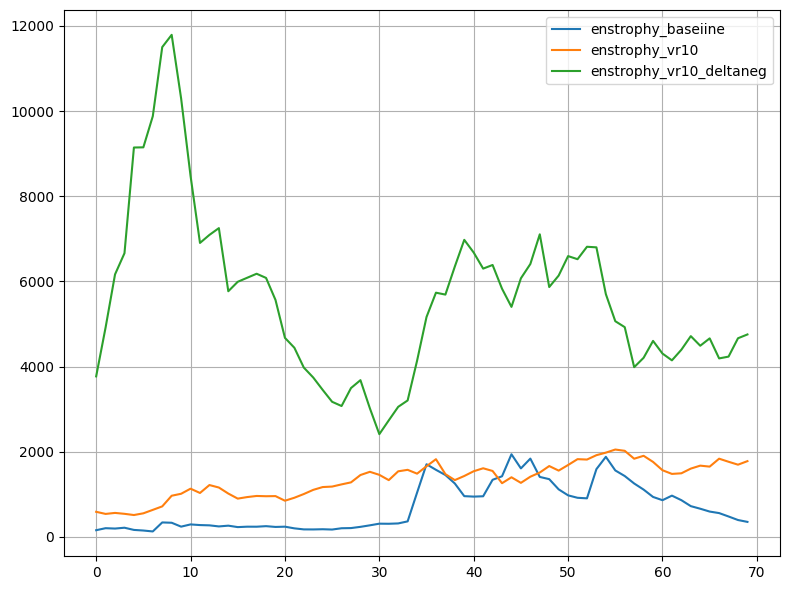

In [28]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + '/' + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()